# 05b_W: Women's Ensemble Modeling + Combined Submission

**Prerequisites:**
- Men's: `04a` -> `04b` -> `05b_ensemble_modeling` (produces `submission_ensemble_v1.csv`)
- Women's: `04a_W` -> `04b_W` -> **this notebook**

### This notebook:
1. Trains XGBoost + LightGBM + Logistic Regression on women's data
2. Blends into women's ensemble
3. Generates women's 2026 predictions
4. **Combines men's + women's into final Kaggle submission**

### Key Difference from Men's
- No Massey rankings -> fewer features (11 after correlation drops, vs 12 for men's)
- Training data from 2010+ (vs 2003+ for men's)

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
from sklearn.calibration import calibration_curve

from src.data_loader import load_sample_submission, load_teams, PROCESSED_DIR
from src.utils import validate_submission, parse_submission_id

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)

GENDER = 'W'

teams = load_teams(GENDER)
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))

print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")

XGBoost: 3.2.0
LightGBM: 4.6.0


In [2]:
# Load women's matchup features
matchups = pd.read_csv(PROCESSED_DIR / 'matchup_features_W.csv')
print(f"Women's matchups: {len(matchups):,} rows")
print(f"Seasons: {matchups['Season'].min()} to {matchups['Season'].max()}")
print(f"GameType: {matchups['GameType'].value_counts().to_dict()}")

# Load women's team features (for 2026 predictions)
team_features = pd.read_csv(PROCESSED_DIR / 'team_features_W.csv')
print(f"\nWomen's team features: {len(team_features):,} rows")

# Load sample submission (contains both M and W)
sample_sub = load_sample_submission(stage=2)
print(f"\nFull sample submission: {len(sample_sub):,} rows")

Women's matchups: 80,701 rows
Seasons: 2010 to 2026
GameType: {'Regular': 79740, 'Tournament': 961}

Women's team features: 5,966 rows

Full sample submission: 132,133 rows


---
## 2. Feature Selection & Train/Val Split

In [3]:
# Drop correlated features (same logic as men's, minus Massey rankings)
# Drop: WinPct (corr w/ Elo, AvgMargin), AvgPointsFor/Against (redundant w/ AvgMargin),
#        Last15WinPct (corr w/ Last15AvgMargin)
drop_cols = ['WinPct_Diff', 'AvgPointsFor_Diff', 'AvgPointsAgainst_Diff', 'Last15WinPct_Diff']

feature_cols = [c for c in matchups.columns if c.endswith('_Diff') and c not in drop_cols]

matchups = matchups.drop(columns=drop_cols, errors='ignore')

print(f"Women's feature columns ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")

Women's feature columns (11):
  AvgMargin_Diff
  eFG_Off_Diff
  TORate_Off_Diff
  ORBRate_Off_Diff
  FTRate_Off_Diff
  Elo_RegSeason_Diff
  SeedNum_Diff
  IsSeeded_Diff
  ConfStrength_Rank_Diff
  Last15AvgMargin_Diff
  ConfTourneyChamp_Diff


In [4]:
# Time-based split
train_data = matchups[matchups['Season'] <= 2024].copy()
val_data = matchups[matchups['Season'] == 2025].copy()

train_clean = train_data.dropna(subset=feature_cols)
val_clean = val_data.dropna(subset=feature_cols)

X_train = train_clean[feature_cols]
y_train = train_clean['Target']

X_val = val_clean[feature_cols]
y_val = val_clean['Target']

# Tournament-only validation
val_tourney = val_clean[val_clean['GameType'] == 'Tournament'].copy()
X_val_t = val_tourney[feature_cols]
y_val_t = val_tourney['Target']

print(f"Training:     {X_train.shape[0]:,} rows ({train_data['Season'].min()}-{train_data['Season'].max()})")
print(f"Validation:   {X_val.shape[0]:,} rows (2025 all games)")
print(f"Val Tourney:  {len(val_tourney)} rows (2025 tournament only)")
print(f"Features:     {X_train.shape[1]}")

Training:     71,464 rows (2010-2024)
Validation:   5,459 rows (2025 all games)
Val Tourney:  67 rows (2025 tournament only)
Features:     11


---
## 3. Model 1: XGBoost

In [5]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=3.0,
    early_stopping_rounds=150,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"\nBest iteration: {xgb_model.best_iteration}")
print(f"Best validation log loss: {xgb_model.best_score:.4f}")

[0]	validation_0-logloss:0.68917	validation_1-logloss:0.68897
[100]	validation_0-logloss:0.57313	validation_1-logloss:0.57016
[200]	validation_0-logloss:0.56251	validation_1-logloss:0.56040
[300]	validation_0-logloss:0.55986	validation_1-logloss:0.55948
[400]	validation_0-logloss:0.55815	validation_1-logloss:0.55938
[500]	validation_0-logloss:0.55637	validation_1-logloss:0.55957
[521]	validation_0-logloss:0.55600	validation_1-logloss:0.55955

Best iteration: 371
Best validation log loss: 0.5593


In [6]:
# XGBoost tournament evaluation
xgb_preds_tourney = xgb_model.predict_proba(X_val_t)[:, 1]
xgb_brier = brier_score_loss(y_val_t, xgb_preds_tourney)
xgb_ll = log_loss(y_val_t, xgb_preds_tourney)
xgb_acc = accuracy_score(y_val_t, (xgb_preds_tourney > 0.5).astype(int))

print(f"Women's XGBoost — 2025 Tournament:")
print(f"  Brier Score: {xgb_brier:.4f}")
print(f"  Log Loss:    {xgb_ll:.4f}")
print(f"  Accuracy:    {xgb_acc:.1%}")

Women's XGBoost — 2025 Tournament:
  Brier Score: 0.1388
  Log Loss:    0.4364
  Accuracy:    80.6%


---
## 4. Model 2: Logistic Regression

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_val_t_scaled = scaler.transform(X_val_t)

lr_model = LogisticRegression(
    C=0.5,
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)

lr_preds_tourney = lr_model.predict_proba(X_val_t_scaled)[:, 1]
lr_brier = brier_score_loss(y_val_t, lr_preds_tourney)
lr_ll = log_loss(y_val_t, lr_preds_tourney)
lr_acc = accuracy_score(y_val_t, (lr_preds_tourney > 0.5).astype(int))

print(f"Women's Logistic Regression — 2025 Tournament:")
print(f"  Brier Score: {lr_brier:.4f}")
print(f"  Log Loss:    {lr_ll:.4f}")
print(f"  Accuracy:    {lr_acc:.1%}")

Women's Logistic Regression — 2025 Tournament:
  Brier Score: 0.1347
  Log Loss:    0.4270
  Accuracy:    85.1%


---
## 5. Model 3: LightGBM

In [8]:
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.02,
    num_leaves=15,
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_samples=20,
    reg_alpha=0.5,
    reg_lambda=3.0,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

lgb_preds_tourney = lgb_model.predict_proba(X_val_t)[:, 1]
lgb_brier = brier_score_loss(y_val_t, lgb_preds_tourney)
lgb_ll = log_loss(y_val_t, lgb_preds_tourney)
lgb_acc = accuracy_score(y_val_t, (lgb_preds_tourney > 0.5).astype(int))

print(f"\nWomen's LightGBM — 2025 Tournament:")
print(f"  Brier Score: {lgb_brier:.4f}")
print(f"  Log Loss:    {lgb_ll:.4f}")
print(f"  Accuracy:    {lgb_acc:.1%}")

Training until validation scores don't improve for 150 rounds
[100]	training's binary_logloss: 0.572871	valid_1's binary_logloss: 0.570238
[200]	training's binary_logloss: 0.562526	valid_1's binary_logloss: 0.560835
[300]	training's binary_logloss: 0.560007	valid_1's binary_logloss: 0.560109
[400]	training's binary_logloss: 0.558375	valid_1's binary_logloss: 0.560131
[500]	training's binary_logloss: 0.556739	valid_1's binary_logloss: 0.560295
Early stopping, best iteration is:
[352]	training's binary_logloss: 0.559146	valid_1's binary_logloss: 0.560069

Women's LightGBM — 2025 Tournament:
  Brier Score: 0.1405
  Log Loss:    0.4414
  Accuracy:    82.1%


---
## 6. Ensemble Blend

In [9]:
# Grid search blend weights
best_brier = 1.0
best_weights = None
results = []

for w_xgb in np.arange(0.0, 1.01, 0.1):
    for w_lr in np.arange(0.0, 1.01 - w_xgb, 0.1):
        w_lgb = round(1.0 - w_xgb - w_lr, 1)
        if w_lgb < 0:
            continue
        
        blend = w_xgb * xgb_preds_tourney + w_lr * lr_preds_tourney + w_lgb * lgb_preds_tourney
        brier = brier_score_loss(y_val_t, blend)
        ll = log_loss(y_val_t, blend)
        acc = accuracy_score(y_val_t, (blend > 0.5).astype(int))
        
        results.append({
            'w_XGB': round(w_xgb, 1), 'w_LR': round(w_lr, 1), 'w_LGB': round(w_lgb, 1),
            'Brier': brier, 'LogLoss': ll, 'Accuracy': acc
        })
        
        if brier < best_brier:
            best_brier = brier
            best_weights = (round(w_xgb, 1), round(w_lr, 1), round(w_lgb, 1))

results_df = pd.DataFrame(results).sort_values('Brier')

print("TOP 10 BLEND WEIGHTS (by Brier Score):")
print("=" * 70)
display(results_df.head(10))

w_xgb, w_lr, w_lgb = best_weights
print(f"\nBest blend: XGB={w_xgb}, LR={w_lr}, LGB={w_lgb}")
print(f"Best Brier: {best_brier:.4f}")

TOP 10 BLEND WEIGHTS (by Brier Score):


,w_XGB,w_LR,w_LGB,Brier,LogLoss,Accuracy
10,0.0,1.0,0.0,0.134695,0.427007,0.850746
20,0.1,0.9,0.0,0.135025,0.427815,0.850746
9,0.0,0.9,0.1,0.135178,0.428302,0.850746
29,0.2,0.8,0.0,0.135372,0.428650,0.835821
19,0.1,0.8,0.1,0.135525,0.429136,0.835821
8,0.0,0.8,0.2,0.135681,0.429627,0.835821
37,0.3,0.7,-0.0,0.135738,0.429514,0.835821
28,0.2,0.7,0.1,0.135889,0.429998,0.835821
18,0.1,0.7,0.2,0.136045,0.430488,0.835821
44,0.4,0.6,-0.0,0.136121,0.430406,0.835821



Best blend: XGB=0.0, LR=1.0, LGB=0.0
Best Brier: 0.1347


In [10]:
# Final comparison
ensemble_preds_tourney = w_xgb * xgb_preds_tourney + w_lr * lr_preds_tourney + w_lgb * lgb_preds_tourney
ens_brier = brier_score_loss(y_val_t, ensemble_preds_tourney)
ens_ll = log_loss(y_val_t, ensemble_preds_tourney)
ens_acc = accuracy_score(y_val_t, (ensemble_preds_tourney > 0.5).astype(int))

print("=" * 60)
print("WOMEN'S MODEL COMPARISON — 2025 Tournament")
print("=" * 60)

final_comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Logistic Regression', 'LightGBM',
              f'ENSEMBLE ({w_xgb}/{w_lr}/{w_lgb})'],
    'Brier Score': [xgb_brier, lr_brier, lgb_brier, ens_brier],
    'Log Loss': [xgb_ll, lr_ll, lgb_ll, ens_ll],
    'Accuracy': [xgb_acc, lr_acc, lgb_acc, ens_acc]
})
display(final_comparison)

WOMEN'S MODEL COMPARISON — 2025 Tournament


,Model,Brier Score,Log Loss,Accuracy
0,XGBoost,0.138801,0.436380,0.805970
1,Logistic Regression,0.134695,0.427007,0.850746
2,LightGBM,0.140467,0.441391,0.820896
3,ENSEMBLE (0.0/1.0/0.0),0.134695,0.427007,0.850746


---
## 7. Calibration Plot

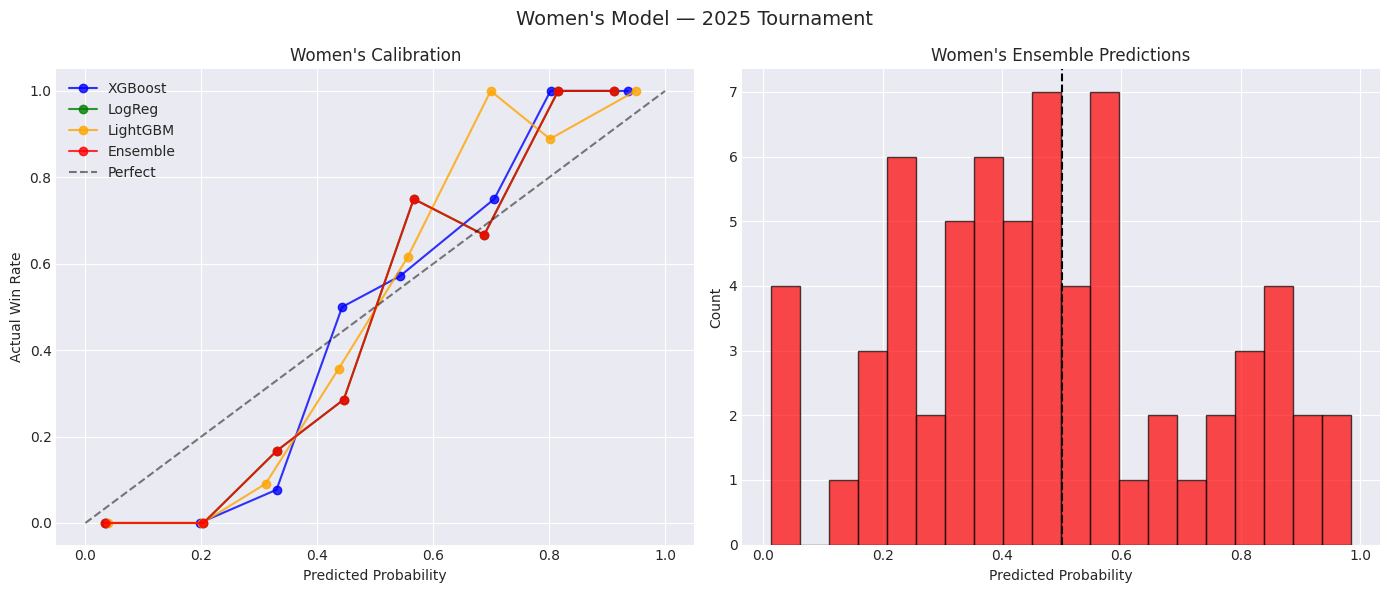

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, preds, color in [
    ('XGBoost', xgb_preds_tourney, 'blue'),
    ('LogReg', lr_preds_tourney, 'green'),
    ('LightGBM', lgb_preds_tourney, 'orange'),
    ('Ensemble', ensemble_preds_tourney, 'red')
]:
    prob_true, prob_pred = calibration_curve(y_val_t, preds, n_bins=8)
    axes[0].plot(prob_pred, prob_true, 'o-', label=name, color=color, alpha=0.8)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Actual Win Rate')
axes[0].set_title("Women's Calibration")
axes[0].legend()

axes[1].hist(ensemble_preds_tourney, bins=20, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title("Women's Ensemble Predictions")

plt.suptitle("Women's Model — 2025 Tournament", fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Generate Women's 2026 Predictions

In [12]:
# Filter sample submission to women's games only (TeamID >= 3000)
women_sub = sample_sub[sample_sub['ID'].apply(
    lambda x: int(x.split('_')[1]) >= 3000
)].copy()
print(f"Women's submission rows: {len(women_sub):,}")

# Parse IDs
sub_matchups = []
for sub_id in women_sub['ID']:
    season, team1, team2 = parse_submission_id(sub_id)
    sub_matchups.append({'ID': sub_id, 'Season': season, 'Team1': team1, 'Team2': team2})

sub_df = pd.DataFrame(sub_matchups)
print(f"Parsed: {len(sub_df):,} matchups")

Women's submission rows: 65,703
Parsed: 65,703 matchups


In [13]:
# Build features using 2025 women's stats
features_2025 = team_features[team_features['Season'] == 2025].copy()
print(f"Women's teams with 2025 stats: {len(features_2025)}")

# Team-level features (without _Diff) — must match feature_cols
diff_features = ['AvgMargin',
                 'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off',
                 'Elo_RegSeason',
                 'SeedNum', 'IsSeeded',
                 'ConfStrength_Rank', 'Last15AvgMargin', 'ConfTourneyChamp']

sub_features = []
missing_teams = set()

for _, row in sub_df.iterrows():
    t1 = features_2025[features_2025['TeamID'] == row['Team1']]
    t2 = features_2025[features_2025['TeamID'] == row['Team2']]
    
    feat_row = {'ID': row['ID']}
    
    if len(t1) == 0 or len(t2) == 0:
        if len(t1) == 0:
            missing_teams.add(row['Team1'])
        if len(t2) == 0:
            missing_teams.add(row['Team2'])
        for col in feature_cols:
            feat_row[col] = 0.0
        sub_features.append(feat_row)
        continue
    
    t1, t2 = t1.iloc[0], t2.iloc[0]
    for col in diff_features:
        val1, val2 = t1.get(col, np.nan), t2.get(col, np.nan)
        feat_row[f'{col}_Diff'] = val1 - val2 if pd.notna(val1) and pd.notna(val2) else 0.0
    
    sub_features.append(feat_row)

sub_feat_df = pd.DataFrame(sub_features)
X_sub = sub_feat_df[feature_cols].fillna(0.0)

print(f"Submission features built: {len(sub_feat_df):,}")
if missing_teams:
    print(f"Teams without 2025 data: {len(missing_teams)} (will predict ~0.5)")

Women's teams with 2025 stats: 362
Submission features built: 65,703
Teams without 2025 data: 1 (will predict ~0.5)


In [14]:
# Generate ensemble predictions for women's 2026
xgb_sub_preds = xgb_model.predict_proba(X_sub)[:, 1]
lr_sub_preds = lr_model.predict_proba(scaler.transform(X_sub))[:, 1]
lgb_sub_preds = lgb_model.predict_proba(X_sub)[:, 1]

women_preds = w_xgb * xgb_sub_preds + w_lr * lr_sub_preds + w_lgb * lgb_sub_preds
women_preds = np.clip(women_preds, 0.01, 0.99)

women_submission = pd.DataFrame({
    'ID': sub_feat_df['ID'],
    'Pred': women_preds
})

print(f"Women's predictions:")
print(f"  Rows:  {len(women_submission):,}")
print(f"  Mean:  {women_submission['Pred'].mean():.3f}")
print(f"  Std:   {women_submission['Pred'].std():.3f}")
print(f"  Range: [{women_submission['Pred'].min():.3f}, {women_submission['Pred'].max():.3f}]")

Women's predictions:
  Rows:  65,703
  Mean:  0.511
  Std:   0.298
  Range: [0.010, 0.990]


---
## 9. Combine Men's + Women's into Final Submission

In [15]:
import os

sub_dir = PROCESSED_DIR.parent / 'submissions'

# Load men's ensemble submission
men_submission = pd.read_csv(sub_dir / 'submission_ensemble_v1.csv')

# Keep only men's rows (TeamID < 3000)
men_only = men_submission[men_submission['ID'].apply(
    lambda x: int(x.split('_')[1]) < 3000
)].copy()

print(f"Men's predictions:   {len(men_only):,} rows")
print(f"Women's predictions: {len(women_submission):,} rows")
print(f"Expected total:      {len(sample_sub):,} rows")

Men's predictions:   66,430 rows
Women's predictions: 65,703 rows
Expected total:      132,133 rows


In [16]:
# Combine men's + women's
combined = pd.concat([men_only, women_submission], ignore_index=True)
combined = combined.sort_values('ID').reset_index(drop=True)

print(f"Combined submission: {len(combined):,} rows")
print(f"Sample submission:   {len(sample_sub):,} rows")
print(f"Match: {len(combined) == len(sample_sub)}")

# Validate
validation_result = validate_submission(combined, sample_sub)
print(f"\nValid: {validation_result['valid']}")
if validation_result['errors']:
    print(f"Errors: {validation_result['errors']}")
if validation_result['warnings']:
    print(f"Warnings: {validation_result['warnings']}")

# Check men's vs women's
men_rows = combined[combined['ID'].apply(lambda x: int(x.split('_')[1]) < 3000)]
women_rows = combined[combined['ID'].apply(lambda x: int(x.split('_')[1]) >= 3000)]
print(f"\nBreakdown:")
print(f"  Men's:   {len(men_rows):,} rows, mean pred={men_rows['Pred'].mean():.3f}")
print(f"  Women's: {len(women_rows):,} rows, mean pred={women_rows['Pred'].mean():.3f}")

Combined submission: 132,133 rows
Sample submission:   132,133 rows
Match: True

Valid: True

Breakdown:
  Men's:   66,430 rows, mean pred=0.492
  Women's: 65,703 rows, mean pred=0.511


In [17]:
# Save final combined submission
output_path = sub_dir / 'submission_combined_ensemble_v1.csv'
combined.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {combined.shape}")
print(f"\nThis is the file to upload to Kaggle!")

# Also save women's separately for reference
women_path = sub_dir / 'submission_women_ensemble_v1.csv'
women_submission.to_csv(women_path, index=False)
print(f"\nAlso saved women's only: {women_path}")

Saved: /home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/submissions/submission_combined_ensemble_v1.csv
Shape: (132133, 2)

This is the file to upload to Kaggle!

Also saved women's only: /home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/submissions/submission_women_ensemble_v1.csv


In [18]:
# Show top predicted women's matchups
w_names = women_submission.copy()
parsed = w_names['ID'].str.split('_', expand=True)
w_names['Team1'] = parsed[1].astype(int)
w_names['Team2'] = parsed[2].astype(int)
w_names['Team1Name'] = w_names['Team1'].map(team_lookup)
w_names['Team2Name'] = w_names['Team2'].map(team_lookup)

print("Women's TOP 10: Team1 heavily favored:")
display(w_names.sort_values('Pred', ascending=False)[['Team1Name', 'Team2Name', 'Pred']].head(10))

print("\nWomen's TOP 10: Team2 heavily favored:")
display(w_names.sort_values('Pred', ascending=True)[['Team1Name', 'Team2Name', 'Pred']].head(10))

Women's TOP 10: Team1 heavily favored:


,Team1Name,Team2Name,Pred
18491,Connecticut,Indiana St,0.99
18492,Connecticut,Iona,0.99
18496,Connecticut,IUPUI,0.99
18466,Connecticut,Gardner Webb,0.99
18473,Connecticut,Grambling,0.99
18475,Connecticut,Hampton,0.99
18497,Connecticut,Jackson St,0.99
18458,Connecticut,Florida A&M,0.99
18449,Connecticut,SIUE,0.99
18452,Connecticut,Evansville,0.99



Women's TOP 10: Team2 heavily favored:


,Team1Name,Team2Name,Pred
61372,St Francis PA,USC,0.01
43675,MA Lowell,TCU,0.01
53530,Northeastern,TCU,0.01
2914,American Univ,Connecticut,0.01
20263,CS Northridge,Duke,0.01
56864,Presbyterian,UCLA,0.01
15327,Chicago St,Duke,0.01
34774,Houston Chr,USC,0.01
48967,MS Valley St,TCU,0.01
56847,Presbyterian,Texas,0.01


---
## Summary

### Pipeline
```
Men's:    04a -> 04b -> 05b_ensemble  -> submission_ensemble_v1.csv
Women's:  04a_W -> 04b_W -> THIS NOTEBOOK -> submission_women_ensemble_v1.csv
Combined: ^^^ merged here ^^^         -> submission_combined_ensemble_v1.csv  <-- UPLOAD THIS
```

### Files Produced
| File | Description |
|------|-------------|
| `submission_combined_ensemble_v1.csv` | **Upload to Kaggle** (men's + women's) |
| `submission_women_ensemble_v1.csv` | Women's only (for reference) |
| `submission_ensemble_v1.csv` | Men's only (from 05b) |